# Analyse univariée et bivariée des données
## TP fil rouge : Parcoursup 2025

**Données** : formations proposées sur Parcoursup en 2025 (ministère de l'Enseignement supérieur, data.enseignementsup-recherche.gouv.fr).

**Organisation** : en binôme, un dépôt GitHub par binôme. Un commit à la fin de chaque partie.

Pour chaque question : du code, **et** une interprétation rédigée. Un chiffre sans phrase ne vaut rien.

---

### 🎯 La question de l'enquête

> **Qu'est-ce qui rend une formation sélective sur Parcoursup ?**

La sélectivité se mesure avec `taux_acces_ens` : la part des candidats qui ont reçu une proposition d'admission. Plus il est **bas**, plus la formation est **sélective**.

Chaque partie du TP fait avancer l'enquête. À la fin de chaque jour, vous rédigez une synthèse : *ce qu'on sait à ce stade sur la sélectivité*. La conclusion finale fait partie du TP noté.

# J1 matin — Comprendre les fondements de l'univarié

## Mise en place

Créez votre dépôt GitHub, clonez-le, placez `parcoursup.csv` dans un dossier `data/`.

In [253]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Chargez le fichier (séparateur : `;`). Combien de lignes et de colonnes ?

In [254]:
df = pd.read_csv('data\parcoursup.csv', sep=';', index_col=0)
df 

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\User\AppData\Local\Temp\ipykernel_8404\3549075661.py:1: SyntaxWarning: invalid escape sequence '\p'
  df = pd.read_csv('data\parcoursup.csv', sep=';', index_col=0)
C:\Users\User\AppData\Local\Temp\ipykernel_8404\3549075661.py:1: DtypeWarning: Columns (110: detail_forma2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data\parcoursup.csv', sep=';', index_col=0)


,contrat_etab,cod_uai,g_ea_lib_vx,dep,dep_lib,region_etab_aff,acad_mies,ville_etab,lib_for_voe_ins,select_form,...,tri,cod_aff_form,detail_forma2,lien_form_psup,taux_acces_ens,part_acces_gen,part_acces_tec,part_acces_pro,etablissement_id_paysage,composante_id_paysage
session,,,,,,,,,,,,,,,,,,,,,
2025,Public,0121471J,Institut national universitaire Champollion - ...,12,Aveyron,Occitanie,Toulouse,Rodez,Licence - Sciences et Techniques des Activités...,formation non sélective,...,1_universités,2519,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,7.0,93,5,2,NaN,NaN
2025,Privé enseignement supérieur,0753605L,FAC LIBRE THEOLOGIE PROTESTANT,75,Paris,Ile-de-France,Paris,Paris 14e Arrondissement,Licence - Théologie - Parcours Théologie prote...,formation non sélective,...,1_universités,25320,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,90,5,5,NaN,NaN
2025,Privé enseignement supérieur,0951809A,CY ILEPS,95,Val-d'oise,Ile-de-France,Versailles,Cergy,Licence - Sciences de l'éducation et de la for...,formation sélective,...,1_universités,25370,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,77.0,80,16,5,NaN,NaN
2025,Public,0922671D,I.U.T de Ville d'Avray - Antenne de Nanterre,92,Hauts-de-Seine,Ile-de-France,Versailles,Nanterre,BUT - Techniques de commercialisation,formation sélective,...,1_universités,25438,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,12.0,48,52,0,NaN,NaN
2025,Privé enseignement supérieur,0690195M,Institut Catholique de Lyon,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 2e Arrondissement,Licence - Double diplôme - Licence Droit - Dou...,formation sélective,...,1_universités,25443,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,60.0,100,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,Privé sous contrat d'association,0754030Y,Lycée Albert de Mun,75,Paris,Ile-de-France,Paris,Paris 7e Arrondissement,Mise à niveau - Hôtellerie restauration,formation sélective,...,3_Autres formations,9500,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,69.0,61,26,14,NaN,NaN
2025,Privé sous contrat d'association,0754030Y,Lycée Albert de Mun,75,Paris,Ile-de-France,Paris,Paris 7e Arrondissement,Diplôme de Comptabilité et de Gestion,formation sélective,...,3_Autres formations,9501,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,53.0,73,27,0,NaN,NaN
2025,Public,0754476H,Lycée des Métiers de l'Hôtellerie Guillaume TIREL,75,Paris,Ile-de-France,Paris,Paris 14e Arrondissement,Mise à niveau - Hôtellerie restauration,formation sélective,...,3_Autres formations,9541,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,16.0,72,19,9,NaN,NaN


## 1. Typologie des variables

🎯 *Enquête* : avant de chercher ce qui explique la sélectivité, il faut savoir quelles variables on a et comment les traiter.

Classez au moins ces colonnes : `fili`, `contrat_etab`, `select_form`, `cod_uai`, `capa_fin`, `voe_tot`, `taux_acces_ens`, `pct_bours`. Pour chacune : codage (ce que voit pandas), nature statistique, traitement retenu et justification.

| Variable       | Codage | Nature statistique    | Traitement retenu    | Justification                                                                                            |
| -------------- | ------ | --------------------- | -------------------- | -------------------------------------------------------------------------------------------------------- |
| fili           | string | nominale              | discrétiser | Les filières sont des catégories de fotmation et sans ordre.  |
| contrat_etab   | string | nominale              | fréquence / comptage | Les catégories représentent différents types d’établissement, sans ordre naturel.                        |
| select_form    | string | nominale              | fréquence / comptage | Il y a 2 catégories sans ordre naturel. On peut compter les occurrences de chacune.                      |
| cod_uai        | string | nominale              | aucun                | Il s’agit d’un identifiant d’établissement. Les codes ne représentent pas une quantité ni un ordre.      |
| capa_fin       | entier | quantitative discrète | aucun                | C’est un nombre de places. Les valeurs sont entières et peuvent être conservées telles quelles.          |
| voe_tot        | entier | quantitative discrète | aucun                | C’est un nombre de vœux. Il s’agit d’un comptage avec des valeurs entières.                              |
| taux_acces_ens | réel   | quantitative continue | aucun                | C’est un taux exprimé en pourcentage. Il peut être conservé comme valeur numérique.                      |
| pct_bours      | réel   | quantitative continue | aucun                | C’est un pourcentage qui peut être conservé comme valeur numérique.                                      |


> 💾 **Commit** : « Typologie des variables »

## 2. Tendance centrale

🎯 *Enquête* : à quoi ressemble une formation « typique » ? Est-elle sélective ? On regarde d'abord la sélectivité, puis deux causes possibles : la demande (`voe_tot`) et la taille (`capa_fin`).

**2.1** Moyenne et médiane de `taux_acces_ens`. Que remarquez-vous ?

In [255]:
moyenne_ta = df['taux_acces_ens'].mean()
mediane_ta = df['taux_acces_ens'].median()
print ("Moyenne_ta :", moyenne_ta)
print ("Médiane_ta :", mediane_ta)

Moyenne_ta : 56.14736250614596
Médiane_ta : 54.0


**Interprétation** : on constate que la moyenne est proche de la médiane, alors les données sont assez symetrique. alors les formations sont pas assez sélectives et plus d'1 personne reçoit une acceptaion.

**2.2** Moyenne et médiane de `voe_tot`. Une formation très demandée sera-t-elle forcément sélective ? Gardez la question en tête.

In [256]:
moyenne = df['voe_tot'].mean()
mediane = df['voe_tot'].median()
print("Moyenne voeux totaux :", moyenne)
print("Médiane :", mediane)

Moyenne voeux totaux : 947.4028206567499
Médiane : 385.0


**Interprétation** :la moyenne est largement surperieur à médiane. Alors une formation reçoit en médiane 385 voeux, la moyenne de voeux est élévée parce qu'il y a des formations qui reçoivent plus de voeux. Mais cela ne veut pas dire que plus une formation est demandé plus elle est sélective


**2.3** Quelle formation a la plus grande capacité (`capa_fin`) ? Que deviennent la moyenne et la médiane sans elle ?

In [257]:
# Formation avec la plus grande capacité
max_cap = df['capa_fin'].max()
formation_max = df.loc[df['capa_fin'].idxmax(), 'lib_for_voe_ins']

print("Capacité maximale :", max_cap)
print("Formation concernée :", formation_max)

Capacité maximale : 3400
Formation concernée : session
2025    Licence - Sciences et Techniques des Activités...
2025    Licence - Théologie - Parcours Théologie prote...
2025    Licence - Sciences de l'éducation et de la for...
2025                BUT - Techniques de commercialisation
2025    Licence - Double diplôme - Licence Droit - Dou...
                              ...                        
2025              Mise à niveau - Hôtellerie restauration
2025                Diplôme de Comptabilité et de Gestion
2025              Mise à niveau - Hôtellerie restauration
2025    Classe préparatoire aux études supérieures - S...
2025                                         Architecture
Name: lib_for_voe_ins, Length: 14252, dtype: str


In [258]:
df_sans_max = df[df['capa_fin'] != max_cap]
print("Moyenne de capa_fin :", df['capa_fin'].mean())
print("Médiane de capa_fin :", df['capa_fin'].median())
print("Moyenne sans la plus grande capacité :", df_sans_max['capa_fin'].mean())
print("Médiane sans la plus grande capacité :", df_sans_max['capa_fin'].median())

Moyenne de capa_fin : 53.98196744316587
Médiane de capa_fin : 30.0
Moyenne sans la plus grande capacité : 53.747175636797415
Médiane sans la plus grande capacité : 30.0


**Interprétation** : On constate que la médiane avec ou sans la cap max reste la même, maisla moyenne diminue légérèment.ça veut dire Cela indique que la capacité typique des formations est d’environ 30 places, et que quelques formations très grandes tirent légèrement la moyenne vers le haut

**2.4** Mode de `fili` et de `contrat_etab`.

In [259]:
mode_fili = df['fili'].mode()
print ("Mode :", mode_fili)
mode_contrat_etab = df['contrat_etab'].mode()
print ("Mode :", mode_contrat_etab)


Mode : 0    BTS
Name: fili, dtype: str
Mode : 0    Public
Name: contrat_etab, dtype: str


**Interprétation** : on constate que la formation qui apparait le plus c'est le bts et plus dans des établissements publics.

> 💾 **Commit** : « Tendance centrale »

## 3. Dispersion

🎯 *Enquête* : les formations sont-elles toutes à peu près aussi sélectives, ou y a-t-il de grands écarts à expliquer ?

On étudie la dispersion de `voe_tot` de bout en bout, puis on la compare à `taux_acces_ens`.

**3.1** Étendue de `voe_tot` (minimum, maximum, étendue).

In [260]:
max_voe_tot = df['voe_tot'].max()
min_voe_tot = df['voe_tot'].min()
etendue = max_voe_tot - min_voe_tot
print("Valeur maximale de voe_tot :", max_voe_tot)
print("Valeur minimale de voe_tot :", min_voe_tot)
print("Étendue de voe_tot :", etendue)

Valeur maximale de voe_tot : 19404
Valeur minimale de voe_tot : 1
Étendue de voe_tot : 19403


**Interprétation** : l'étendue montre qu'il y a véritablement une asymétrie car la médiane est de 385 et la moyenne 947. On constate qu'il y a des formations plus demandées que d'autres. Cela indique une forte dispersion des niveaux de demande, ce qui peut expliquer une sélectivité très différente selon les formations.

**3.2** Variance pas à pas sur les **10 premières formations** : écarts à la moyenne, écarts au carré, somme des écarts. Calculez la variance en divisant par n, puis par n − 1. Vérifiez avec numpy et pandas.

In [261]:
df_10_formations = df.sample(n=10, random_state=35)

x = df_10_formations['voe_tot']

moyenne = x.mean()
    
ecarts = x - moyenne
ecarts_carres = ecarts**2

somme_carres = ecarts_carres.sum()

variance_population = somme_carres / len(x)

variance_echantillon = somme_carres / (len(x) - 1)

print("10 formations choisies :")
print(x)
print("\nMoyenne :", moyenne)
print("Écarts à la moyenne :", ecarts.to_list())
print("Écarts au carré :", ecarts_carres.to_list())
print("Somme des écarts au carré :", somme_carres)
print("Variance population (÷ n) :", variance_population)
print("Variance échantillon (÷ n-1) :", variance_echantillon)


print("\nVérification NumPy :")
print("var n =", np.var(x))
print("var n-1 =", np.var(x, ddof=1))

print("\nVérification pandas :")
print("var_n :", x.var(ddof=0))
print("var_n-1 :", x.var())

10 formations choisies :
session
2025    1263
2025    1799
2025    1322
2025    1355
2025     100
2025     131
2025     182
2025    1094
2025      27
2025     851
Name: voe_tot, dtype: int64

Moyenne : 812.4
Écarts à la moyenne : [450.6, 986.6, 509.6, 542.6, -712.4, -681.4, -630.4, 281.6, -785.4, 38.60000000000002]
Écarts au carré : [203040.36000000002, 973379.56, 259692.16000000003, 294414.76, 507513.75999999995, 464305.95999999996, 397404.16, 79298.56000000001, 616853.1599999999, 1489.9600000000019]
Somme des écarts au carré : 3797392.4000000004
Variance population (÷ n) : 379739.24000000005
Variance échantillon (÷ n-1) : 421932.4888888889

Vérification NumPy :
var n = 379739.24000000005
var n-1 = 421932.4888888889

Vérification pandas :
var_n : 379739.24000000005
var_n-1 : 421932.4888888889


**Interprétation** : le degré de liberté à un impact, aussi les valeur sont ecartées vu qu'il ya une forte dispersion. Certaines formations sont beaucoup plus demandées que d’autres, et cet écart est visible dans les valeurs élevées de variance.

**3.3** Calculez tous les indicateurs de dispersion de `voe_tot` : variance, écart-type, écart absolu moyen, Q1, Q3, IQR, coefficient de variation. Comparez l'écart-type, l'écart absolu moyen et l'IQR.

In [262]:
variance_voe_tot = df['voe_tot'].var()
ecart_type_voe_tot = df['voe_tot'].std()
mae_voe_tot = (df['voe_tot'] - moyenne).abs().mean()
coefficient_variation = ecart_type_voe_tot / moyenne
Q1 = df['voe_tot'].quantile(0.25)
Q3 = df['voe_tot'].quantile(0.75)
IQR = Q3 - Q1
print ("Variance de voe_tot :", variance_voe_tot)
print ("Écart type de voe_tot :", ecart_type_voe_tot)
print ("Ecart absolu moyen :", mae_voe_tot)
print ("Coefficient de variation de voe_tot :", coefficient_variation)
print ("Premier quartile de voe_tot :", Q1)
print ("Troisième quartile de voe_tot :", Q3)
print ("Étendue interquartile de voe_tot :", IQR)

Variance de voe_tot : 2509634.0870399703
Écart type de voe_tot : 1584.182466460215
Ecart absolu moyen : 871.7116895874263
Coefficient de variation de voe_tot : 1.9500030360170053
Premier quartile de voe_tot : 160.0
Troisième quartile de voe_tot : 1016.0
Étendue interquartile de voe_tot : 856.0


**Interprétation** : IQR est proche du mae et l’écart-type de 1584,18 est sensiblement plus élevé que l’écart absolu moyen de 871,71 et que l’IQR de 856,0, ce qui indique une forte dispersion asmétrique. Cela indique que la demande en vœux est très dispersée et qu’elle est notamment tirée vers le haut par quelques formations très demandées. La moitié centrale des formations se situe entre 160 et 1016 vœux, mais la dispersion globale reste forte.

**3.4** Comparez la dispersion de `voe_tot` et de `taux_acces_ens` (écart-type, IQR, coefficient de variation). Laquelle est la plus dispersée ? Qu'est-ce que ça dit des écarts de sélectivité entre formations ?

In [263]:
variance_ta = df['taux_acces_ens'].var()
ecart_type_ta = df['taux_acces_ens'].std()
mae = (df['taux_acces_ens'] - moyenne_ta).abs().mean()
coefficient_variation_ta = ecart_type_ta / moyenne_ta
Q1_ta = df['taux_acces_ens'].quantile(0.25)
Q3_ta = df['taux_acces_ens'].quantile(0.75)
IQR_ta = Q3_ta - Q1_ta
print ("Variance de taux_acces_ens :", variance_ta)
print ("Écart-type de taux_acces_ens :", ecart_type_ta)
print ("MAE de taux_acces_ens :", mae)
print ("Coefficient de variation de taux_acces_ens :", coefficient_variation_ta)
print ("Q1 de taux_acces_ens :", Q1_ta)
print ("Q3 de taux_acces_ens :", Q3_ta)
print ("IQR de taux_acces_ens :", IQR_ta)

Variance de taux_acces_ens : 817.4264423617664
Écart-type de taux_acces_ens : 28.590670547606372
MAE de taux_acces_ens : 24.519874203921514
Coefficient de variation de taux_acces_ens : 0.5092077218137682
Q1 de taux_acces_ens : 33.0
Q3 de taux_acces_ens : 81.0
IQR de taux_acces_ens : 48.0


**Interprétation** : On remarque que par rapport aux voeux, la dispersion est plus centrée et assez symétrique et que l'écart-type est superieur à l'écart absolu moyen (MAE) et inferieur à l'écart inter-quartile (IQR). Ce qui indique la demande est présente, que les niveaux de demande varient beaucoup plus fortement d’une formation à l’autre que les taux d’accès. Les écarts de sélectivité existent, mais ils sont moins importants que les écarts de volume de demandes entre formations.

> 💾 **Commit** : « Dispersion »

## 4. Graphiques

🎯 *Enquête* : voir la sélectivité, et trouver un premier indice de ce qui la fait varier.

**4.1** Histogramme de `taux_acces_ens`. À quelle forme vous attendiez-vous ? Qu'obtenez-vous ?

Text(0.5, 1.0, 'Histogramme de taux_acces_ens')

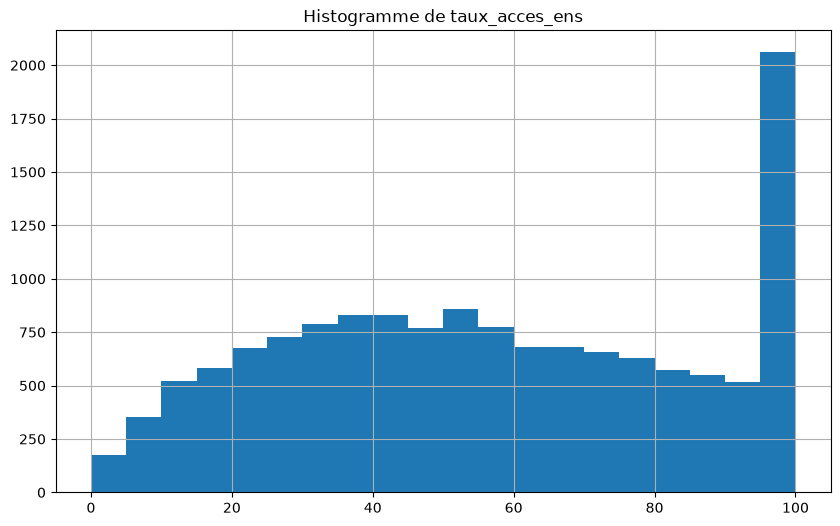

In [264]:
plt.figure(figsize=(10, 6))
hist_taux_acces_ens = df['taux_acces_ens'].hist(bins=20)
plt.title("Histogramme de taux_acces_ens")

**Interprétation** : Nous pouvons dire que l'histogramme du taux d'accès aux formations est plus tirée vers la gauche, et assez donc dispersé. la queue est épaisse. On constate que l’histogramme semble asymétrique à gauche : beaucoup de formations ont un taux d’accès élevé, tandis qu’un plus petit nombre ont un taux faible. Ces formations à faible taux d’accès sont potentiellement les plus sélectives. La dispersion montre que les taux d’accès varient d’une formation à l’autre.

**4.2** Diagramme en barres de `fili`, trié par effectif.

Text(0, 0.5, 'Effectif')

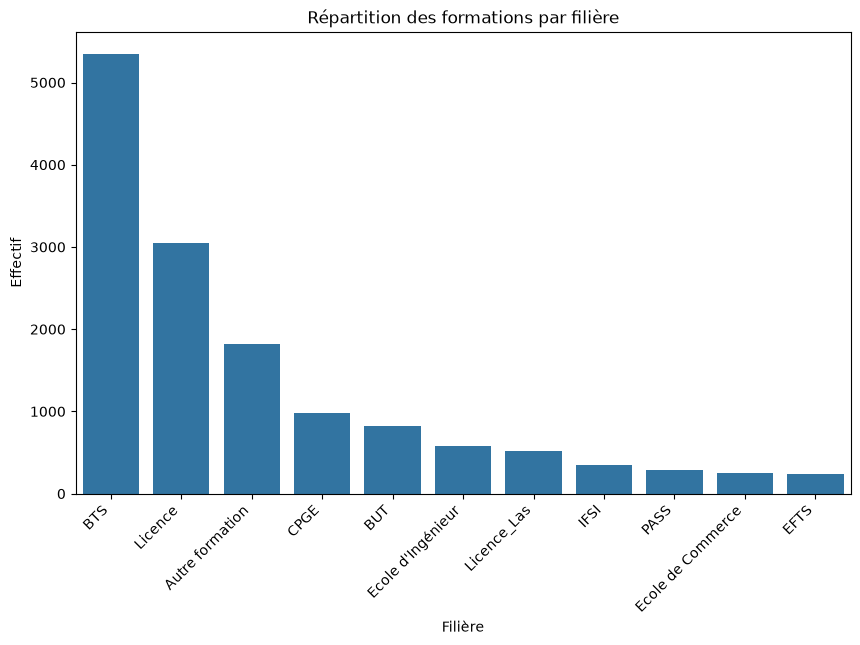

In [265]:
#diagramme en barre
import seaborn as sns
effectifs_fili = df['fili'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=effectifs_fili.index, y=effectifs_fili.values)
plt.xticks(rotation=45, ha='right')
plt.title("Répartition des formations par filière")
plt.xlabel("Filière")
plt.ylabel("Effectif")


**4.2 bis** Camembert de `contrat_etab`, puis camembert de `fili`. Lequel est lisible ? Pourquoi ?

Text(0.5, 1.0, 'Répartition des filières')

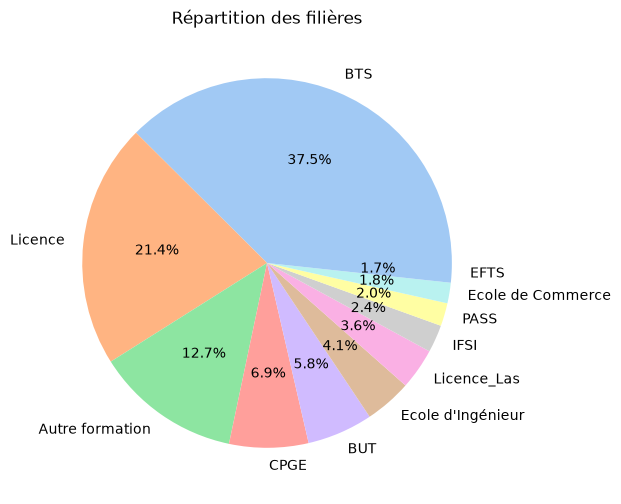

In [266]:
couleurs = sns.color_palette("pastel")
plt.figure(figsize=(10, 6))
plt.pie(df['fili'].value_counts(), labels=df['fili'].value_counts().index, autopct='%1.1f%%', colors=couleurs)
plt.title("Répartition des filières")

Text(0.5, 1.0, "Répartition des contrats d'établissement")

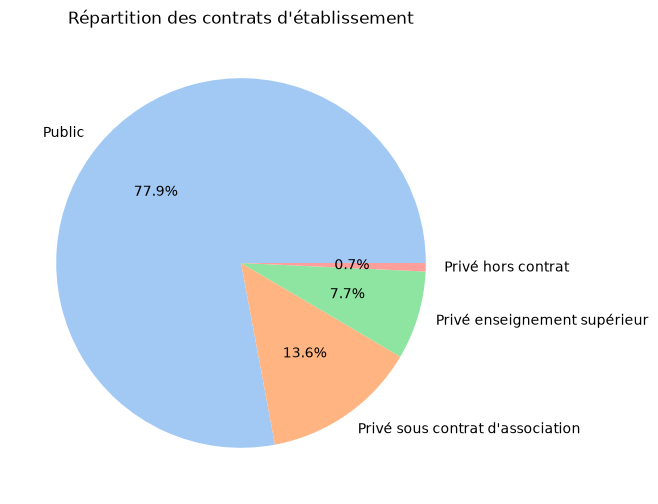

In [267]:
couleurs = sns.color_palette("pastel")
plt.figure(figsize=(10, 6))
plt.pie(df['contrat_etab'].value_counts(), labels=df['contrat_etab'].value_counts().index, autopct='%1.1f%%', colors=couleurs)
plt.title("Répartition des contrats d'établissement")

**Interprétation** : Le camembert de contrat_etab est le plus lisible, car il y a peu de catégories à comparer. Celui de fili est moins lisible : il contient beaucoup de modalités, donc les parts sont difficiles à distinguer. Ces graphiques montrent la répartition des formations, mais ne permettent pas de conclure sur leur sélectivité.

**4.3** Boxplot de `voe_tot`. Est-il lisible ? Que faudrait-il faire ?

<Axes: xlabel='voe_tot'>

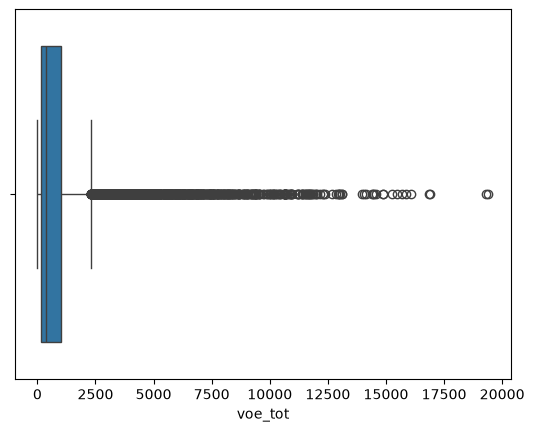

In [268]:
sns.boxplot(x='voe_tot', data=df)

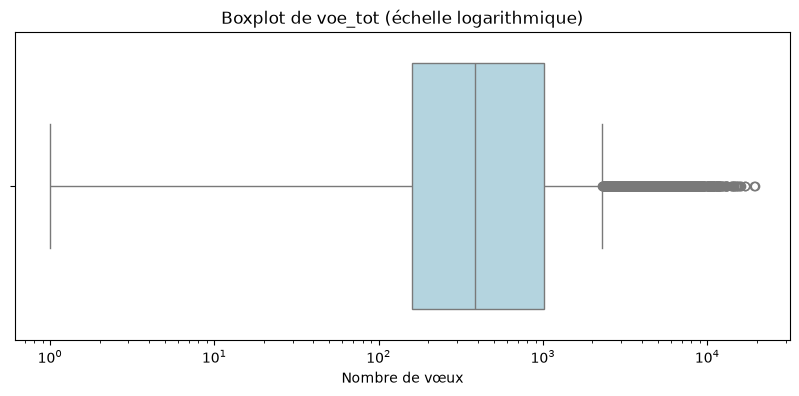

In [269]:
df_voe = df[df["voe_tot"] > 0]
plt.figure(figsize=(10, 4))
sns.boxplot(x="voe_tot", data=df_voe, color='lightblue')
plt.xscale("log")
plt.title("Boxplot de voe_tot (échelle logarithmique)")
plt.xlabel("Nombre de vœux")
plt.show()


**Interprétation** : On constate que les formations reçoivent environ entre 160 et 1 016 vœux, avec une médiane autour de 385. Les nombreux points au-delà montrent que certaines formations reçoivent beaucoup plus de vœux que la majorité. L’échelle logarithmique permet de mieux visualiser ces grands écarts.

**4.4** Boxplots de `taux_acces_ens` selon `select_form`. Premier indice : le label « sélective » correspond-il vraiment à un taux d'accès plus faible ?

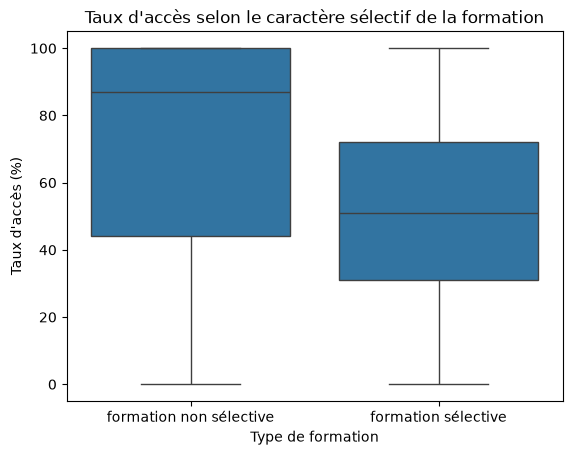

                         min  median    max       mean
select_form                                           
formation non sélective  0.0    87.0  100.0  72.263537
formation sélective      0.0    51.0  100.0  51.484151


In [270]:
df = df.reset_index(drop=True)
sns.boxplot(data=df, x="select_form", y="taux_acces_ens")
plt.title("Taux d'accès selon le caractère sélectif de la formation")
plt.xlabel("Type de formation")
plt.ylabel("Taux d'accès (%)")
plt.show()

print(df.groupby("select_form")["taux_acces_ens"].agg(["min", "median", "max", "mean"]))


**Interprétation** :  On constate que les formations non sélectives ont une médiane de taux d’accès plus élevée que les formations sélectives. La médiane est de 87 % pour les formations non sélectives, contre 51 % pour les formations sélectives. Leur dispersion semble également plus importante. Cela indique que le label « sélective » est cohérent avec un taux d’accès plus faible, même si les taux varient au sein de chaque catégorie.

> 💾 **Commit** : « Graphiques », puis **push**.

# J1 après-midi — Approfondir les distributions

In [271]:
from scipy import stats

## 5. Asymétrie et aplatissement

🎯 *Enquête* : la forme des variables décidera des outils à utiliser au J2 pour les relier à la sélectivité.

**5.1** Calculez la skewness et la kurtosis de `voe_tot`, `taux_acces_ens`, `capa_fin` et `pct_bours`. Classez-les de la plus symétrique à la plus asymétrique. Lesquelles faudra-t-il transformer avant de les relier à la sélectivité ?

In [272]:
variables = ["voe_tot", "taux_acces_ens", "capa_fin", "pct_bours"]
skewness = {}
kurtosis = {}

for variable in variables:
    valeurs = df[variable].dropna()
    skewness[variable] = stats.skew(valeurs)
    kurtosis[variable] = stats.kurtosis(valeurs)

resume_forme = pd.DataFrame({
    "skewness": skewness,
    "kurtosis": kurtosis,
})
resume_forme["ordre"] = resume_forme["skewness"].abs()
resume_forme = resume_forme.sort_values("ordre")
print(resume_forme)

                 skewness    kurtosis      ordre
taux_acces_ens   0.026666   -1.136778   0.026666
pct_bours        1.127673    1.917238   1.127673
voe_tot          4.077600   22.684446   4.077600
capa_fin        12.698444  281.999964  12.698444


**Interprétation** : 

-`taux_acces_ens` : sa skewness (0,027) est très proche de 0, donc la distribution est presque symétrique. Sa kurtosis (-1,137) indique des queues moins lourdes que celles d'une distribution normale.",

"- `pct_bours` : sa skewness (1,128) indique une asymétrie modérée à droite : quelques formations ont des pourcentages de boursiers particulièrement élevés. Sa kurtosis (1,917) suggère des queues plus lourdes que celles d'une distribution normale.",

"- `voe_tot` : sa skewness (4,078) indique une forte asymétrie à droite : quelques formations reçoivent beaucoup plus de vœux que la majorité. Sa kurtosis élevée (22,684) confirme la présence de valeurs extrêmes importantes.",

"- `capa_fin` : c'est la variable la plus asymétrique à droite (skewness = 12,698). Sa kurtosis très élevée (282) , ce qui révèle des capacités grandes par rapport à la majorité des formations.",
    "",



> 💾 **Commit** : « Asymétrie »

## 6. La loi normale

🎯 *Enquête* : peut-on utiliser sur la sélectivité les outils qui supposent une loi normale ?

**6.1** Vérifiez la règle 68-95-99,7 sur `taux_acces_ens`. La variable suit-elle une loi normale ? Quelle conséquence pour la suite de l'enquête ?

In [273]:
print("Moyenne des taux d'accès:", moyenne_ta)
ecart_type_taux  = df["taux_acces_ens"].std()
print("Écart-type des taux d'accès:", ecart_type_taux)

Moyenne des taux d'accès: 56.14736250614596
Écart-type des taux d'accès: 28.590670547606372


In [274]:
taux = df["taux_acces_ens"].dropna()

for k, pourcentage_theorique in [(1, 68), (2, 95), (3, 99.7)]:
    proportion = ((taux >= moyenne_ta- k * ecart_type_taux) &
                  (taux <= moyenne_ta + k * ecart_type_taux)).mean() * 100
    print(f"Dans l'intervalle moyenne +/- {k} ecart-type(s) : {proportion:.2f}% (repere normal : {pourcentage_theorique}%)")

Dans l'intervalle moyenne +/- 1 ecart-type(s) : 58.64% (repere normal : 68%)
Dans l'intervalle moyenne +/- 2 ecart-type(s) : 100.00% (repere normal : 95%)
Dans l'intervalle moyenne +/- 3 ecart-type(s) : 100.00% (repere normal : 99.7%)


**Interprétation**: Les proportions diffèrent de ceux attendues pour une justifier une loi normale car on à 58,64 % à moins d’un écart-type, 100 % à moins de deux et 100 % à moins de trois, contre 68 %, 95 % et 99,7 % attendus pour une loi normale. Alors la colonne taux_acces_ens ne suit pas une loi normale. Il confirme l'interprétation du graphe au dessus.

> 💾 **Commit** : « Loi normale »

## 7. Les distributions réelles

🎯 *Enquête* : la demande (`voe_tot`) est une cause possible de sélectivité. Quelle échelle faudra-t-il utiliser pour la comparer au taux d'accès ?

**7.1** Tracez l'histogramme de `voe_tot`, puis celui de `log(voe_tot)`. Quelle loi reconnaissez-vous ? Quelle échelle utiliserez-vous au J2 pour relier la demande à la sélectivité ?

Text(0, 0.5, 'Fréquence')

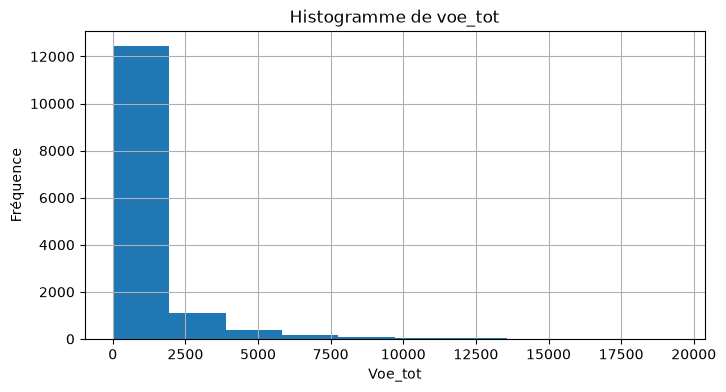

In [275]:
plt.figure(figsize=(8, 4))
hist_voe_tot = df['voe_tot'].hist(bins=10)
plt.title("Histogramme de voe_tot")
plt.xlabel("Voe_tot")
plt.ylabel("Fréquence")

Text(0, 0.5, 'Fréquence')

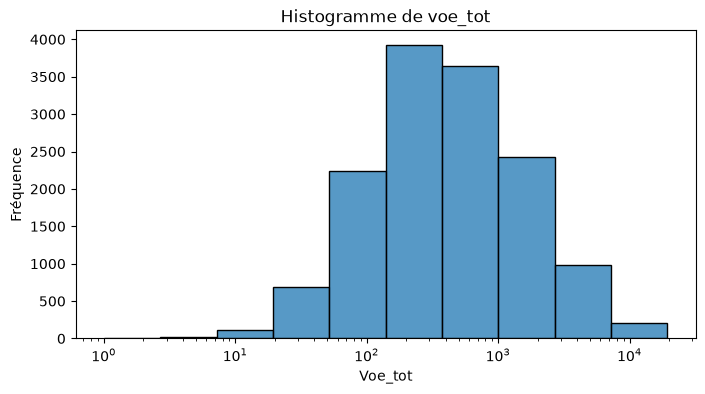

In [276]:
df_voe_tot = df[df["voe_tot"] > 0]
plt.figure(figsize=(8, 4))
sns.histplot(df_voe_tot['voe_tot'], bins=10, log_scale=True)
plt.title("Histogramme de voe_tot")
plt.xlabel("Voe_tot")
plt.ylabel("Fréquence")


**Interprétation** : On constaste que dans l'histograme des voeux, la distrivution est asyémtrique avec une queue vers la droite : la plupart des formations reçoivent relativement peu de vœux, tandis que quelques-unes en reçoivent beaucoup., tandis qu'à l'échelle logarithme, histogramme est plus symétrique et en forme de cloche, cela suggère que les vœux transformés se rapprochent davantage d’une distribution normale, mais on ne peut ps dire qu'elle suit la loi normale.

**7.2** Quelle part des vœux concentrent les 10 % et les 20 % de formations les plus demandées ? Est-ce une distribution de type Pareto ?

In [277]:
voeux_valides = df["voe_tot"].dropna().sort_values(ascending=False)
total_voeux = voeux_valides.sum()
n_formations = len(voeux_valides)

for part in [0.10, 0.20]:
    n_top = int(np.ceil(part * n_formations))
    voeux_top = voeux_valides.iloc[:n_top].sum()
    part_voeux = voeux_top / total_voeux * 100
    print(f"Top {part:.0%} : {n_top} formations sur {n_formations}")
    print(f"Part des vœux concentrés : {part_voeux:.2f}%\n")

part_cumulee_formations = np.arange(1, n_formations + 1) / n_formations * 100
part_cumulee_voeux = voeux_valides.cumsum() / total_voeux * 100



Top 10% : 1426 formations sur 14252
Part des vœux concentrés : 49.83%

Top 20% : 2851 formations sur 14252
Part des vœux concentrés : 67.99%



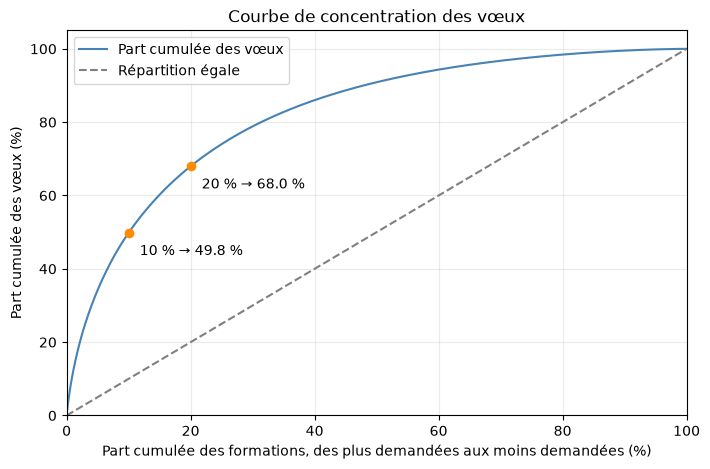

In [278]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(part_cumulee_formations, part_cumulee_voeux, color="steelblue", label="Part cumulée des vœux")
plt.plot([0, 100], [0, 100], "--", color="gray", label="Répartition égale")

for x in [10, 20]:
    y = np.interp(x, part_cumulee_formations, part_cumulee_voeux)
    plt.scatter(x, y, color="darkorange", zorder=3)
    plt.annotate(f"{x} % → {y:.1f} %", (x, y), xytext=(8, -16), textcoords="offset points")


plt.xlabel("Part cumulée des formations, des plus demandées aux moins demandées (%)")
plt.ylabel("Part cumulée des vœux (%)")
plt.title("Courbe de concentration des vœux")
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

**Interprétation** : Les 10 % de formations qui reçoivent le plus de vœux concentrent environ 49,83 % de l’ensemble des vœux. Les 20 % les plus demandées en concentrent environ 67,99 %. Les vœux sont donc fortement concentrés dans une partie des formations. Toutefois, le résultat ne correspond pas exactement à la règle de Pareto classique.

> 💾 **Commit** : « Distributions »

## 8. Outliers

🎯 *Enquête* : les formations hors norme risquent de fausser les liens avec la sélectivité. Faut-il les garder ?

**8.1** Détectez les outliers de `capa_fin` avec la méthode IQR, puis avec le Z-score (|z| > 3). Comparez les nombres obtenus et expliquez l'écart.

In [279]:
Outliers_iqr = df[(df["voe_tot"] < Q1 - 1.5 * IQR) | (df["voe_tot"] > Q3 + 1.5 * IQR)]
print("Nombre d'outliers détectés :", len(Outliers_iqr))

Nombre d'outliers détectés : 1441


In [280]:
outliers_zscore = df[(np.abs(stats.zscore(df["voe_tot"])) > 3)]
print("Nombre d'outliers détectés avec Z-score :", len(outliers_zscore))

Nombre d'outliers détectés avec Z-score : 340


**Interprétation** : Le Z-score détecte moins de d'outliers que la méthode IQR. Vu que voe_tot est fortement asymétrique à droite. Alors c'est mieux de prendre en compte la méthode IQR au profit du le z-score, car quelques formations reçoivent énormément de vœux, ce qui peut augmenter la moyenne et l’écart-type. 

**8.2** Affichez les 10 plus grandes capacités. S'agit-il d'erreurs ou de valeurs réelles ? Que faites-vous ? Les garderez-vous pour étudier la sélectivité ?

In [281]:
colonnes_a_afficher = ["lib_for_voe_ins", "capa_fin", "voe_tot", "taux_acces_ens", "select_form"]
top_10_capacites = df.nlargest(10, "capa_fin")[colonnes_a_afficher]
top_10_capacites

,lib_for_voe_ins,capa_fin,voe_tot,taux_acces_ens,select_form
10282,BTS - Services - Diététique et nutrition - Ent...,3400,1614,100.0,formation sélective
9035,BTS - Services - Communication - Entièrement e...,3200,1189,100.0,formation sélective
7184,BTS - Services - Commerce International - Enti...,2400,1822,100.0,formation sélective
8389,BTS - Services - Tourisme - Entièrement en dis...,2400,1022,100.0,formation sélective
8393,BTS - Services - Management Commercial Opérati...,2400,1224,100.0,formation sélective
5888,BTS - Services - Economie sociale familiale - ...,2000,541,100.0,formation sélective
7185,BTS - Services - Négociation et digitalisation...,2000,1089,100.0,formation sélective
9033,BTS - Services - Services et prestations des s...,2000,607,100.0,formation sélective
1907,Licence - Droit - Parcours Droit (EDS-IED) - E...,1500,4608,100.0,formation non sélective
5889,BTS - Services - Comptabilité et gestion - Ent...,1500,687,100.0,formation sélective


**Interprétation**: On peut que dire que les valeurs réelles après étude et on peut les utiliser pour la sélectivité. Ce qui permet d'avoir une vision d'ensemble de la situation dans un établissement et pour une formation.


> 💾 **Commit** : « Outliers », puis **push**.

## 9. Analyse univariée en autonomie

🎯 *Enquête* : deux nouveaux suspects. Le profil social des admis et la région peuvent-ils jouer sur la sélectivité ?

Vous disposez maintenant de toute la méthode. Analysez **seuls** les deux variables suivantes, en suivant les étapes ci-dessous :
- une variable **quantitative** : `pct_bours` (part de boursiers parmi les admis, en %) ;
- une variable **qualitative** : `region_etab_aff` (région de l'établissement).

| Étape | Variable quantitative | Variable qualitative |
|---|---|---|
| 1. Comprendre | Ce qu'elle mesure, son unité, discrète ou continue | Nominale ou ordinale, liste des modalités |
| 2. Qualité | Valeurs manquantes, 0 suspects, bornes | Valeurs manquantes, modalités mal orthographiées |
| 3. Centre | Moyenne et médiane, comparées | Mode (et médiane si ordinale) |
| 4. Dispersion | σ, IQR, CV | Nombre de modalités, part de la modalité dominante |
| 5. Visualiser | Histogramme, boxplot | Diagramme en barres |
| 6. Forme | Skewness, kurtosis, QQ-plot : quelle loi ? | Répartition équilibrée ou concentrée, modalités rares |
| 7. Extrêmes | IQR ou Z-score selon la forme, puis inspection | — |
| 8. Conclure | Quel résumé, quels outils pour la suite ? | Quel regroupement, quel encodage pour la suite ? |

> Chaque chiffre s'interprète en une phrase.

### Variable quantitative : `pct_bours`

In [282]:
df_bours = df["pct_bours"]
pct_bours_valides = df_bours.dropna()

print("Nombre de valeurs manquantes :", df_bours.isna().sum())
print("Nombre de valeurs hors intervalle [0, 100] :", ((pct_bours_valides < 0) | (pct_bours_valides > 100)).sum())
print("Nombre de zéros :", (pct_bours_valides == 0).sum())
print("\nStatistiques descriptives :")
print(pct_bours_valides.describe())
print("Médiane :", pct_bours_valides.median())
print("Écart-type :", pct_bours_valides.std())
print("Coefficient de variation :", pct_bours_valides.std() / pct_bours_valides.mean())

Q1_pct_bours = pct_bours_valides.quantile(0.25)
Q3_pct_bours = pct_bours_valides.quantile(0.75)
print("Premier quartile :", Q1_pct_bours)
print("Troisième quartile :", Q3_pct_bours)
IQR = Q3_pct_bours - Q1_pct_bours
print("Intervalle interquartile :", IQR)



Nombre de valeurs manquantes : 0
Nombre de valeurs hors intervalle [0, 100] : 0
Nombre de zéros : 1882

Statistiques descriptives :
count    14252.000000
mean        22.267261
std         17.767732
min          0.000000
25%          9.000000
50%         20.000000
75%         32.000000
max        100.000000
Name: pct_bours, dtype: float64
Médiane : 20.0
Écart-type : 17.767732060265075
Coefficient de variation : 0.7979307500571851
Premier quartile : 9.0
Troisième quartile : 32.0
Intervalle interquartile : 23.0


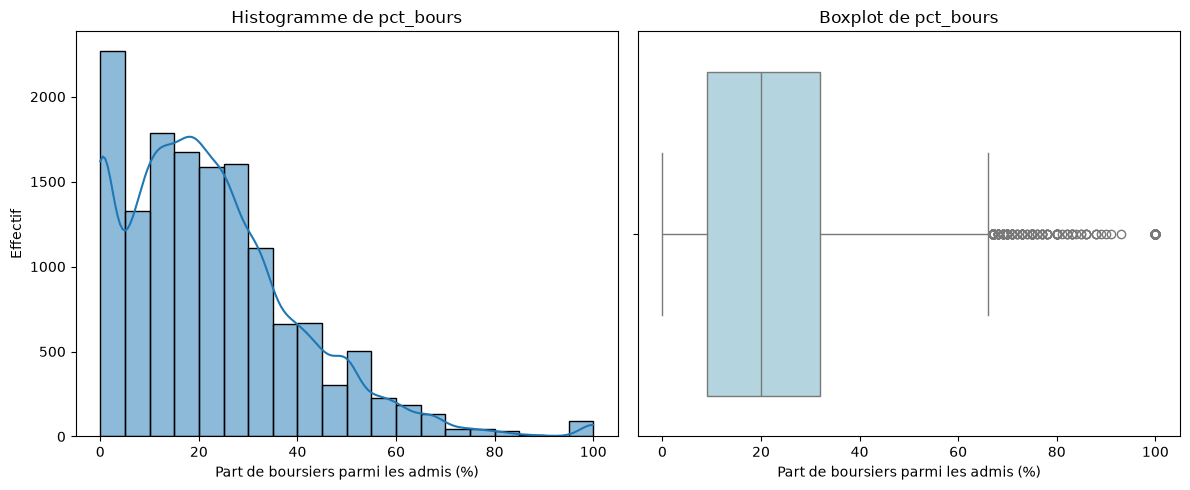

In [283]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(pct_bours_valides, bins=20, kde=True, ax=axes[0])
axes[0].set_title("Histogramme de pct_bours")
axes[0].set_xlabel("Part de boursiers parmi les admis (%)")
axes[0].set_ylabel("Effectif")

sns.boxplot(x=pct_bours_valides, color="lightblue", ax=axes[1])
axes[1].set_title("Boxplot de pct_bours")
axes[1].set_xlabel("Part de boursiers parmi les admis (%)")

plt.tight_layout()
plt.show()

c:\Users\User\Desktop\Cours Analyse univariée & bivariée\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


<Axes: xlabel='pct_bours', ylabel='Count'>

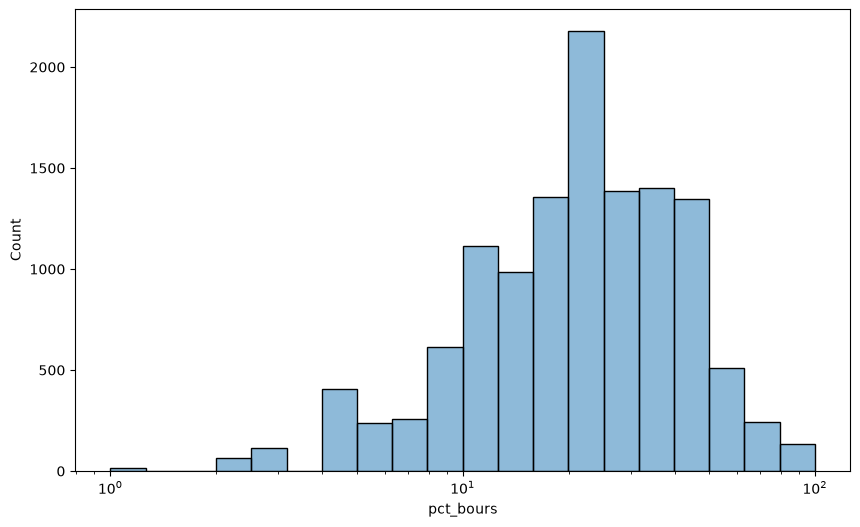

In [284]:
df = df[df["pct_bours"] > 0]
plt.figure(figsize=(10, 6))
sns.histplot(pct_bours_valides, bins=20, kde=True, log_scale=True)

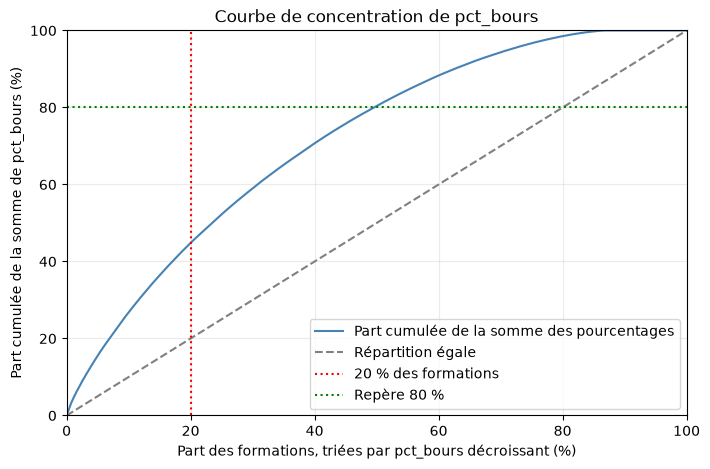

In [285]:
pct_bours_trie = pct_bours_valides.sort_values(ascending=False)
total_pct_bours = pct_bours_trie.sum()
n_formations_bours = len(pct_bours_trie)

part_formations_bours = np.arange(n_formations_bours + 1) / n_formations_bours * 100
part_cumulee_pct_bours = np.insert(
    pct_bours_trie.cumsum().to_numpy() / total_pct_bours * 100,
    0,
    0
)

plt.figure(figsize=(8, 5))
plt.plot(
    part_formations_bours,
    part_cumulee_pct_bours,
    color="steelblue",
    label="Part cumulée de la somme des pourcentages"
)
plt.plot([0, 100], [0, 100], "--", color="gray", label="Répartition égale")
plt.axvline(20, color="red", linestyle=":", label="20 % des formations")
plt.axhline(80, color="green", linestyle=":", label="Repère 80 %")
plt.xlabel("Part des formations, triées par pct_bours décroissant (%)")
plt.ylabel("Part cumulée de la somme de pct_bours (%)")
plt.title("Courbe de concentration de pct_bours")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [286]:
sk_pct_bours = stats.skew(pct_bours_valides)
ku_pct_bours = stats.kurtosis(pct_bours_valides)    
print("Skewness de pct_bours :", sk_pct_bours)
print("Kurtosis de pct_bours :", ku_pct_bours)


Skewness de pct_bours : 1.1276726054873019
Kurtosis de pct_bours : 1.9172382027514425


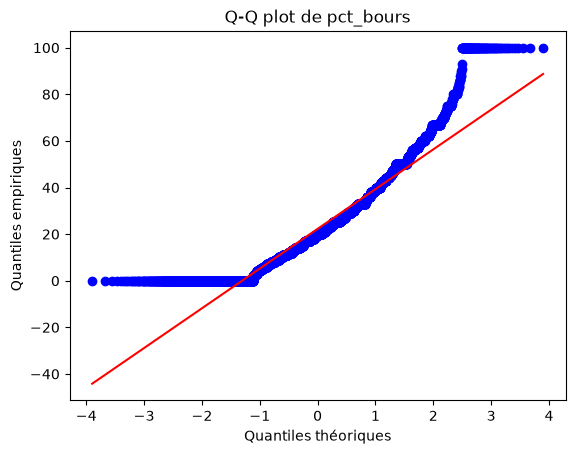

In [287]:

qqplot = stats.probplot(pct_bours_valides, dist="norm", plot=plt)
plt.title("Q-Q plot de pct_bours")
plt.xlabel("Quantiles théoriques")
plt.ylabel("Quantiles empiriques")
plt.show()

In [288]:
outliers_zscore_pb = df[(np.abs(stats.zscore(df["pct_bours"])) > 3)]
print("Nombre d'outliers détectés avec Z-score pour pct_bours :", len(outliers_zscore_pb))

Nombre d'outliers détectés avec Z-score pour pct_bours : 149


In [289]:
outliers_IQR_pb = df[(df["pct_bours"] < Q1_pct_bours - 1.5 * IQR) | (df["pct_bours"] > Q3_pct_bours + 1.5 * IQR)]
print("Nombre d'outliers détectés avec IQR pour pct_bours :", len(outliers_IQR_pb))

Nombre d'outliers détectés avec IQR pour pct_bours : 338


**Analyse** :`pct_bours` est une variable quantitative continue exprimée en pourcentage. La moyenne est d’environ 25 % et la médiane de 22 %. Il y aura surement une distribution assez équilibrée, avec une asymétrie vers les valeurs élevées puisque la moyenne dépasse la médiane. Ainsi, dans une formation typique, la part de boursiers parmi les admis est d’environ 20 % (médiane). 

L’histogramme montre une distribution asymétrique à droite : on peut dire que la plupart des formations ont une part de boursiers faible ou moyenne, tandis que quelques formations ont des valeurs élevées.A l'échelle logarithme  pct_bous suit une loi log normale. Le boxplot confirme cette asymétrie et fait apparaître des valeurs au-dessus de la borne supérieure IQR de 66,5 %. La médiane est de 20 %, et la moitié centrale des formations se situe entre 9 % et 32 %.

Le skewness et le kurtosis sont positif et superieur à 0, ce qui prouve la fait que qu'il y ait une asymétrie vers droite. quelques formations ont une part de boursiers parmi les admis nettement plus élevée que la majorité.
Les 20 % de formations ayant les `pct_bours` les plus élevés représentent environ 41 % de la somme des pourcentages, ce qui indique une certaine concentration, mais pas une règle de Pareto 80/20."

Le Z-score détecte moins de d'outliers que la méthode IQR. Vu que pct_bours est fortement asymétrique à droite. Alors c'est mieux de prendre en compte la méthode IQR au profit du le z-score, car quelques formations reçoivent énormément de, ce qui peut augmenter la moyenne et l’écart-type.

 pct_bours est utile pour étudier si la part de boursiers parmi les admis est associée à la sélectivité.
      

### Variable qualitative : `region_etab_aff`

Valeurs manquantes : 77
Libellés vides : 0
Nombre de régions distinctes : 18
Région la plus représentée : Ile-de-France
Effectif de la région la plus représentée : 2386
Part de la région la plus représentée (%): 19.41

Effectifs et fréquences par région :
                            effectif  frequence_pct
region_etab_aff                                    
Ile-de-France                   2386          19.41
Auvergne-Rhône-Alpes            1493          12.15
Hauts-de-France                 1132           9.21
Occitanie                       1062           8.64
Nouvelle Aquitaine              1009           8.21
Grand-Est                       1003           8.16
Provence-Alpes-Côte d'Azur       870           7.08
Pays-de-la-Loire                 659           5.36
Bretagne                         620           5.04
Normandie                        527           4.29
Bourgogne-Franche-Comté          484           3.94
Centre                           405           3.29
Réunion         

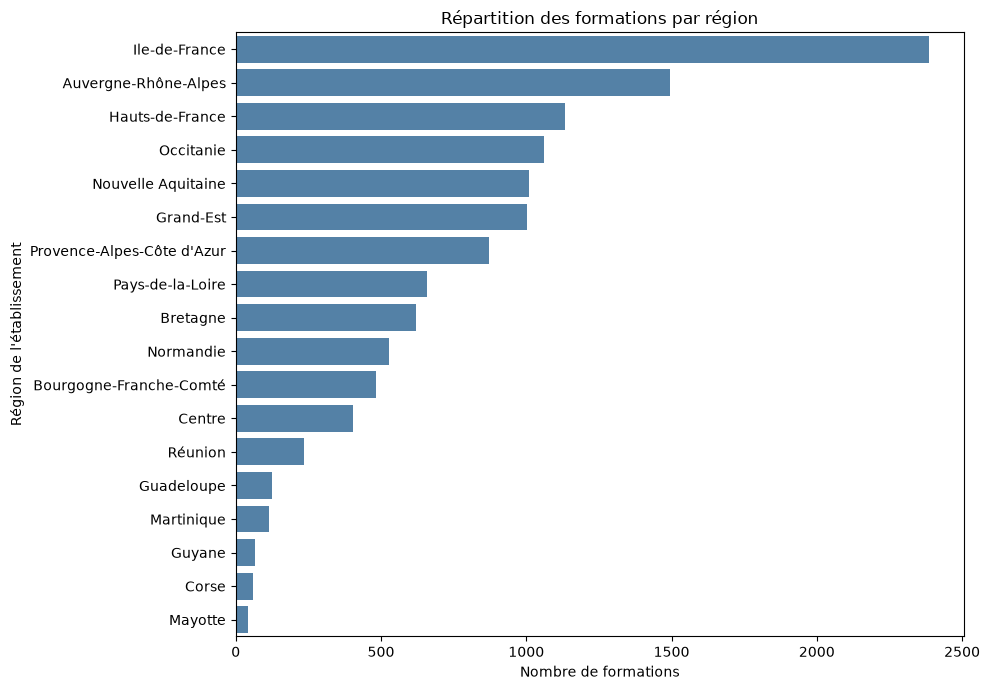

In [290]:
region_brute = df["region_etab_aff"]
nan_regions = region_brute.isna().sum()
vides_regions = region_brute.dropna().astype(str).str.strip().eq("").sum()

regions_valides = (
    region_brute.dropna()
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
    .dropna()
)
effectifs_region = regions_valides.value_counts().sort_values(ascending=False)
frequences_region = (effectifs_region / effectifs_region.sum() * 100).round(2)

print("Valeurs manquantes :", nan_regions)
print("Libellés vides :", vides_regions)
print("Nombre de régions distinctes :", regions_valides.nunique())
print("Région la plus représentée :", effectifs_region.index[0])
print("Effectif de la région la plus représentée :", effectifs_region.iloc[0])
print("Part de la région la plus représentée (%):", frequences_region.iloc[0])
print("\nEffectifs et fréquences par région :")
print(pd.DataFrame({"effectif": effectifs_region, "frequence_pct": frequences_region}))

plt.figure(figsize=(10, 7))
sns.barplot(x=effectifs_region.values, y=effectifs_region.index, color="steelblue")
plt.title("Répartition des formations par région")
plt.xlabel("Nombre de formations")
plt.ylabel("Région de l'établissement")
plt.tight_layout()
plt.show()

**Analyse** : `region_etab_aff` est une variable qualitative nominale : les régions sont des catégories sans ordre naturel. Le jeu de données contient 18 régions renseignées et 97 valeurs manquantes; aucun libellé vide n’a été repéré après suppression des espaces superflus. L’Île-de-France est la modalité la plus représentée avec 2 691 formations, soit 19,01 % des lignes renseignées, suivie par Auvergne-Rhône-Alpes avec 1 730 (12,22 %). Les effectifs sont donc inégalement répartis entre régions, et les territoires outre-mers ainsi que la Corse comptent nettement moins de formations dans ce fichier. Ce diagramme décrit le nombre de formations observées par région; il ne permet pas, à lui seul, de conclure que la région rend une formation plus ou moins sélective.

> 💾 **Commit** : « Analyse univariée », puis **push**.

## 📝 Synthèse J1 — Ce qu'on sait sur la sélectivité

- À quoi ressemble la sélectivité d'une formation typique ? Les formations sont-elles proches ou très différentes ?
- Quels premiers indices avez-vous trouvés sur ce qui la fait varier ?
- Quelles variables faudra-t-il transformer pour la suite, et pourquoi ?

4 à 6 lignes.

**Synthèse** : 
-Une formation typique est plutôt non sélective majoritairement car les formations accueillent beaucoup et parfois même le taux d'accès est proche de 100%. Elles sont plutôt proches même les outliers. Ce sont majoritairement des BTS qui sont en tête en terme de taux d'accès en enseignement publiques. Chez les outliers "BTS Services" avec le parcours qui varie à chaque fois.
-La capacité maximale d'accueil, le taux d'accès, le pourcentage de boursiers dans chacune, le nombre de voeux et de demandes, le type de contrat établi (public, privé),  la région dans lequel la filière s'enseigne. 
-Il faudra transformer le pourcentage de boursiers, le taux d'accès, la capacité maximale notamment.

> 💾 **Commit** : « Synthèse J1 », puis **push**.

# J2 matin — Mettre en pratique les fondements mathématiques de la corrélation

## 10. Covariance

🎯 *Enquête* : on passe au bivarié. On apprend d'abord à mesurer un lien sur un couple simple (capacité × vœux), avant de l'appliquer à la sélectivité.

**10.1** Tracez le nuage de points de `voe_tot` en fonction de `capa_fin`. Calculez leur covariance à la main (produits des écarts), puis avec pandas.

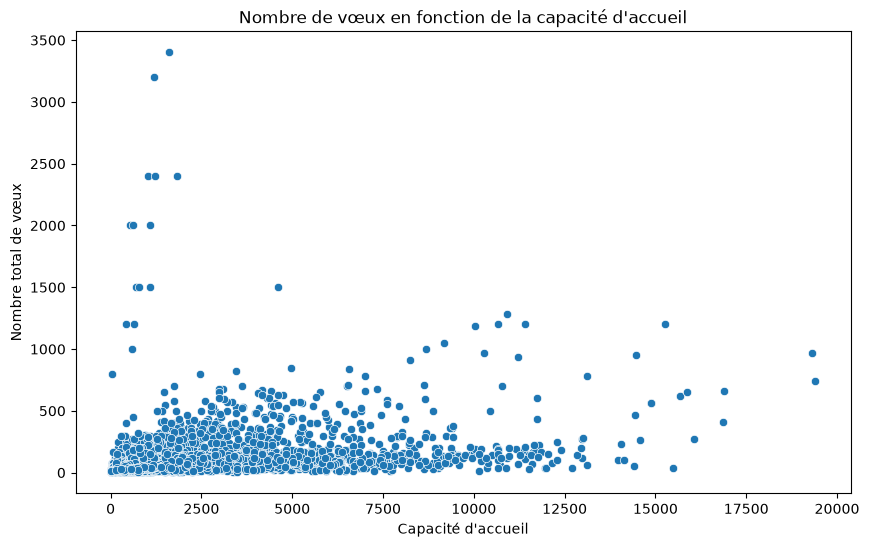

In [291]:
data = df[["capa_fin", "voe_tot"]].dropna()

# Nuage de points
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x = "voe_tot",
    y="capa_fin"
    
)
plt.title("Nombre de vœux en fonction de la capacité d'accueil")
plt.xlabel("Capacité d'accueil")
plt.ylabel("Nombre total de vœux")

plt.show()

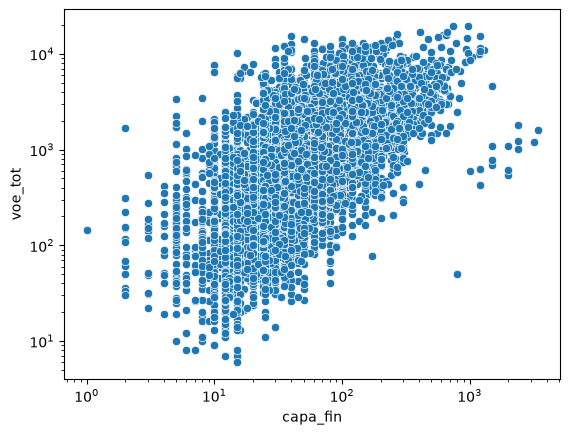

In [292]:
sns.scatterplot(data=data, x="capa_fin", y="voe_tot")
plt.xscale("log")
plt.yscale("log")
plt.show()

In [293]:
x = data["capa_fin"]
y = data["voe_tot"]

# Moyennes
moy_x = x.mean()
moy_y = y.mean()

# Produits des écarts
produits_ecarts = (x - moy_x) * (y - moy_y)

# Covariance échantillonnale
cov_manuel = produits_ecarts.sum() / (len(data) - 1)

cov_pandas = data["capa_fin"].cov(data["voe_tot"])

print("Moyenne capa_fin :", moy_x)
print("Moyenne voe_tot :", moy_y)
print("Somme des produits des écarts :", produits_ecarts.sum())
print("Covariance calculée à la main :", cov_manuel)
print("Covariance avec pandas :", cov_pandas)

Moyenne capa_fin : 59.080274858528696
Moyenne voe_tot : 1037.1670169765562
Somme des produits des écarts : 881096437.1521422
Covariance calculée à la main : 71234.24991124118
Covariance avec pandas : 71234.24991124119


**Interprétation** : La covariance entre la capacité d'accueil et le nombre total de vœux est positive et vaut environ 71 234,25. Cela signifie que les deux variables ont tendance à évoluer dans le même sens : les formations ayant une capacité d'accueil plus importante ont généralement davantage de vœux. Le calcul manuel est confirmé par le calcul effectué avec Pandas.

**10.2** Recalculez la covariance avec la capacité exprimée en centaines de places. Que constatez-vous ?

In [294]:
# Capacité exprimée en centaines de places
data["capa_centaines"] = data["capa_fin"] / 100

cov_avant = data["capa_fin"].cov(data["voe_tot"])
cov_apres = data["capa_centaines"].cov(data["voe_tot"])

print("Covariance avant :", cov_avant)
print("Covariance après :", cov_apres)

Covariance avant : 71234.24991124119
Covariance après : 712.342499112412


**Interprétation** : La covariance entre capa_fin et voe_tot calculée sur les 100 formations est positive (712). Cela indique que, dans cet échantillon, les formations ayant une capacité d'accueil plus élevée ont tendance à avoir également davantage de vœux.

> 💾 **Commit** : « Covariance »

## 11. Corrélation de Pearson

🎯 *Enquête* : première mesure chiffrée du lien entre la demande et la sélectivité.

**11.1** Calculez r entre `capa_fin` et `voe_tot` à la main (covariance / produit des écarts-types), puis avec pandas. Faites de même pour `voe_tot` et `taux_acces_ens`. Que dit ce second coefficient sur la sélectivité ?

In [295]:

data = df[["capa_fin", "voe_tot", "taux_acces_ens"]].dropna()

x = data["capa_fin"]
y = data["voe_tot"]

cov = x.cov(y)
ecart_type_x = x.std()
ecart_type_y = y.std()

r_manuel = cov / (ecart_type_x * ecart_type_y)

print("r (capa_fin, voe_tot) à la main :", r_manuel)

# Avec pandas
r_pandas = data["capa_fin"].corr(data["voe_tot"])

print("r (capa_fin, voe_tot) avec pandas :", r_pandas)

r (capa_fin, voe_tot) à la main : 0.40469330326040803
r (capa_fin, voe_tot) avec pandas : 0.40469330326040825


In [296]:
x = data["voe_tot"]
y = data["taux_acces_ens"]

cov = x.cov(y)
ecart_type_x = x.std()
ecart_type_y = y.std()

r_manuel = cov / (ecart_type_x * ecart_type_y)

print("r (voe_tot, taux_acces_ens) à la main :", r_manuel)

# Avec pandas
r_pandas = data["voe_tot"].corr(data["taux_acces_ens"])

print("r (voe_tot, taux_acces_ens) avec pandas :", r_pandas)

r (voe_tot, taux_acces_ens) à la main : -0.34079527630664747
r (voe_tot, taux_acces_ens) avec pandas : -0.3407952763066476


**Interprétation** : la corrélation entre voe et capa_fin est posisitive, ce qui veut dire que si la capacité augmente les voeux aussi augmente. Ce qui veut dire que plus une formation à de place plus elle est solicitée.

le corrélation entre les voeux et de taux d'accès est négative, ce qui veut dire que si l'un augmente l'autre diminue. Ce qui veut dire plus une formation est solicitée, plus son taux d'accès est faible.

**11.2** Les conditions de Pearson sont-elles respectées ? Recalculez r entre `log(capa_fin)` et `log(voe_tot)` (en excluant les valeurs nulles).

In [297]:
import numpy as np

data_log = df[
    (df["capa_fin"] > 0) &
    (df["voe_tot"] > 0)
][["capa_fin", "voe_tot"]].dropna().copy()

data_log["log_capa_fin"] = np.log(data_log["capa_fin"])
data_log["log_voe_tot"] = np.log(data_log["voe_tot"])

r = data_log["log_capa_fin"].corr(data_log["log_voe_tot"])

print("Coefficient de corrélation :", r)

Coefficient de corrélation : 0.6440209795490646


**Interprétation** : Après utilisation du log on constate que le resultat plus proche du 1 ce qui veut dire qu'il y a une relation linéaire positive entre le nb de voeux et la capacité d'adhésion d'une formation. Pearson est respecté.

> 💾 **Commit** : « Pearson »

## 12. Corrélation de Spearman

🎯 *Enquête* : le lien demande × sélectivité est-il sous-estimé par Pearson ?

**12.1** Calculez Spearman pour les deux couples de la question 11.1. Comparez avec Pearson et expliquez les écarts.

In [298]:

spearman_1 = df["capa_fin"].corr(df["voe_tot"], method="spearman")


spearman_2 = df["voe_tot"].corr(df["taux_acces_ens"], method="spearman")


print("spearman voe et capa :", spearman_1)
print("Spearman :", spearman_2)

spearman voe et capa : 0.6503516476540079
Spearman : -0.47244991164044986


**Interprétation** : Le coefficient de Spearman est de 0,65, tandis que le coefficient de Pearson est de 0,4 pour les données originales. Après transformation logarithmique, le coefficient de Pearson augmente à 0,64. Le coefficient de Spearman est donc plus proche du Pearson calculé sur les logarithmes. Cela montre que la relation entre capa_fin et voe_tot est positive et plutôt monotone, mais qu'elle n'est pas parfaitement linéaire dans les données originales.

Concernant les voeux et les taux d'accès, le coefficient de Pearson est de −0,34 et celui de Spearman de −0,47. Les deux coefficients sont négatifs, ce qui indique une relation inverse entre les deux variables. Les valeurs étant relativement proches, les deux méthodes donnent une conclusion similaire.

> 💾 **Commit** : « Spearman »

## 13. Tests d'hypothèse

🎯 *Enquête* : le lien entre demande et sélectivité est-il réel, ou dû au hasard ? Et quel coefficient retenir pour la suite ?

**13.1** Testez la normalité de `taux_acces_ens` avec Shapiro-Wilk et Anderson-Darling, sur un échantillon de 50 formations puis sur toutes. Formulez H0 et concluez. Quel coefficient de corrélation retiendrez-vous pour la suite de l'enquête ?

In [299]:
df_echantillon = df['taux_acces_ens'].dropna().sample(50, random_state= 50)

shapiro_50 = stats.shapiro(df_echantillon)
anderson_50 = stats.anderson(df_echantillon, dist="norm")
print(shapiro_50)
print(anderson_50)

shapiro_full = stats.shapiro(df["taux_acces_ens"].dropna())
anderson_full = stats.anderson(df["taux_acces_ens"].dropna(), dist="norm")
print("shapiro sur l'ensemble des données :", shapiro_full)
print("anderson sur l'ensemble des données:", anderson_full)

ShapiroResult(statistic=np.float64(0.9576023364703578), pvalue=np.float64(0.07054404794730036))
AndersonResult(statistic=np.float64(0.5076167130617009), critical_values=array([0.552, 0.621, 0.74 , 0.859, 1.019]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(54.6), scale=np.float64(28.280663329691315))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')
shapiro sur l'ensemble des données : ShapiroResult(statistic=np.float64(0.9529224068912038), pvalue=np.float64(2.374114728191358e-52))
anderson sur l'ensemble des données: AndersonResult(statistic=np.float64(135.70429557112948), critical_values=array([0.561, 0.631, 0.752, 0.873, 1.035]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(55.78964820056611), scale=np.float64(28.125834938495924))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


C:\Users\User\AppData\Local\Temp\ipykernel_8404\2744636663.py:4: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  anderson_50 = stats.anderson(df_echantillon, dist="norm")
c:\Users\User\Desktop\Cours Analyse univariée & bivariée\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12365.
  res = hypotest_fun_out(*sam

**Interprétation** : 
H0 : taux_acces_en suit une distribution normale
H1 : taux_acces_en ne suit pas une distribution normale
Avec shapiro sur l'échantillon de 5o on ne rejète pas H0 taux suit une distribution normale et avec anderson la pvalue est significative et on ne rejette pas H0
Avec toute les données, pour shapiro pvalue est inferieur au seuil, alors on rejette H0, alors la la variable ne suit pas une loi normale.
Avec Anderson on rejette H0, alors la variable ne suit pas une loi normale.




**13.2** Testez la corrélation entre `voe_tot` et `taux_acces_ens` (Spearman). Formulez H0, donnez la p-value et concluez. Le lien est-il fort pour autant ?

In [300]:
from scipy.stats import spearmanr

data2 = df[["voe_tot", "taux_acces_ens"]].dropna()

resultat = spearmanr(data["voe_tot"], data2["taux_acces_ens"])

print("Coefficient de Spearman :", resultat.statistic)
print("p-value :", resultat.pvalue)

Coefficient de Spearman : -0.47244991164044986
p-value : 0.0


**Interprétation** : Le ccoef de corrélation nous donne -0,47.
H₀ : il n’existe pas de corrélation entre voe_tot et taux_acces_ens.
H₁ : il existe une corrélation monotone entre les deux variables
vu que la pvalue est inferieur à 0,05, alors on rejette H0 selon laquelle il n'existe pas de corrélation entre les 2 variables. Cependant avec le r de spearman on peut dire qu'il existe une corrélation négative entre les 2 variable, comme pour pour dire, plus il y a de voeux pour une formation, moins il y aura d'accpetation à une formation. 

> 💾 **Commit** : « Tests », puis **push**.

# J2 après-midi — Approfondir les relations quantitatives

## 14. Corrélation partielle

🎯 *Enquête* : le lien entre demande et sélectivité tient-il à capacité égale ?

**14.1** Calculez la corrélation entre `log(voe_tot)` et `taux_acces_ens`, puis la corrélation partielle en contrôlant `log(capa_fin)`. Que concluez-vous ?

In [301]:
data_log = df[
    (df["capa_fin"] > 0) &
    (df["voe_tot"] > 0)
][["capa_fin", "voe_tot", "taux_acces_ens"]].dropna().copy()

data_log["log_capa_fin"] = np.log(data_log["capa_fin"])
data_log["log_voe_tot"] = np.log(data_log["voe_tot"])

corr = spearmanr(
    data_log["log_voe_tot"],
    data_log["taux_acces_ens"]
)

print("Coefficient de Spearman :", corr.statistic)
print("p-value :", corr.pvalue)

Coefficient de Spearman : -0.47244991164044986
p-value : 0.0


In [ ]:
import pingouin as pg
resultat = pg.partial_corr(
    data=data_log,
    x="log_voe_tot",
    y="taux_acces_ens",
    covar="log_capa_fin",
    method="spearman"
)

print(resultat)

              n         r            CI95  p_val
spearman  12365 -0.683273  [-0.69, -0.67]    0.0


**Interprétation** : la corrélation entre log(voe_tot) et le taux d'accueil donne les même valeurs. Par contre avec la corrélation partiel on constate que la pvalue est inférieure au seuil ce qui prouve que la la relation reste significative même en controlant avec log(cap_fin). vu que le r =-0,68, il existe une corrélation négative forte entre le nombre de vœux reçus et le taux d’accès, indépendamment de la capacité d’accueil d'un établissement. Ce qui veut que plus une formation reçoit de vœux, plus son taux d’accès tend à être faible.

> 💾 **Commit** : « Corrélation partielle »

## 15. A/B testing

🎯 *Enquête* : un lien observé suffit-il à affirmer qu'un facteur *cause* la sélectivité ?

**15.1** Au J3, vous verrez que les formations privées ont un taux d'accès plus élevé que les publiques. Peut-on en conclure que le statut privé *rend* une formation moins sélective ? Quelle expérience faudrait-il pour le prouver, et est-elle possible ici ?

**Interprétation** : Non. Une différence entre privé et public montre une association, pas une causalité.

Pour prouver que le privé rend une formation moins sélective, il faudrait une expérience aléatoirement où le statut privé/public serait attribué au hasard. Alors que dans notre cas on je peux juste travailler avec les données qu'on a déjà.

**15.2** Reprenez la simulation de la démo avec 500 visiteurs, puis 20 000. Une version B qui fait passer le taux d'achat de 20 % à 22 %. L'effet est-il détecté dans les deux cas ? Pourquoi ?

**Interprétation** : Avec 500 visiteurs, l’effet de passer de 20 % à 22 % peut ne pas être détecté : l’échantillon est trop petit et les résultats sont trop variables.
Avec 20 000 visiteurs, l’effet est beaucoup plus facilement détecté, car l’échantillon est beaucoup plus grand et l’incertitude baisse.
Ce qui prouve que  plus l’échantillon est grand, plus on peut détecter une petite différence. Ici, l’augmentation de 20 % à 22 % est donc détectable avec 20 000 visiteurs, mais pas forcément avec 500.

> 💾 **Commit** : « A/B testing »

## 16. Matrice de corrélation

🎯 *Enquête* : vue d'ensemble. Quelles variables quantitatives sont liées à la sélectivité, et lesquelles disent la même chose ?

**16.1** Tracez la heatmap des corrélations de Spearman entre `capa_fin`, `voe_tot`, `acc_tot`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb`. Quelles variables sont redondantes ? Quelles variables sont les meilleures candidates pour expliquer la sélectivité ?

**Interprétation** : _à rédiger_

## 17. Régression simple

🎯 *Enquête* : le niveau scolaire des admis explique-t-il la sélectivité, et dans quelle mesure ?

**17.1** Régressez `taux_acces_ens` sur `pct_tb` (part de mentions très bien parmi les admis). Donnez la pente, le R², et tracez les résidus. Les mentions TB expliquent-elles la sélectivité ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Régression », puis **push**.

## 📝 Synthèse J2 — Ce qu'on sait sur la sélectivité

- Quelles variables quantitatives sont liées à la sélectivité, avec quelle force ?
- Le lien avec la demande tient-il quand on contrôle la taille ?
- Peut-on parler de causes ? Pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Synthèse J2 », puis **push**.

# J3 matin — Comprendre les fondements du bivarié qualitatif

## 18. Table de contingence et Chi²

🎯 *Enquête* : le label « formation sélective » dépend-il du statut de l'établissement ?

**18.1** Croisez `select_form` et `contrat_etab` : table des effectifs, puis fréquences conditionnelles par statut.

**Interprétation** : _à rédiger_

**18.2** Faites le test du Chi² d'indépendance (H0, effectifs théoriques, p-value), puis calculez le V de Cramér et les résidus standardisés.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Chi² »

## 19. Quantitatif × qualitatif

🎯 *Enquête* : la sélectivité varie-t-elle selon le statut (public / privé) et selon la filière ?

**19.1** Le `taux_acces_ens` diffère-t-il entre formations publiques et privées ? Boxplot, Student (Welch) et Mann-Whitney.

**Interprétation** : _à rédiger_

**19.2** Le `taux_acces_ens` diffère-t-il selon la filière (`fili`) ? ANOVA et Kruskal-Wallis. Quelles filières sont les plus sélectives ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Quanti × quali », puis **push**.

# J3 après-midi — Introduire le multivarié

## 20. ACP

🎯 *Enquête* : on rassemble toutes les variables. Où se place la sélectivité parmi elles ?

**20.1** Faites une ACP sur `log(capa_fin)`, `log(voe_tot)`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb` (centrées-réduites). Quelle part de variance portent les deux premiers axes ? Interprétez-les à partir des contributions. Où se place `taux_acces_ens` sur ces axes ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « ACP », puis **push**.

## 🏁 Conclusion de l'enquête

Répondez à la question : **qu'est-ce qui rend une formation sélective sur Parcoursup ?**

- Les facteurs retenus, classés par importance, chacun appuyé par un chiffre du TP.
- Les pistes écartées.
- Les limites : ce que vos analyses ne permettent pas d'affirmer.

10 à 15 lignes. Cette conclusion compte dans la note du TP.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Conclusion de l'enquête », puis **push**.